<a href="https://colab.research.google.com/github/dudinha-web/fundamentos-de-ia/blob/main/Aula_12_Geopandas.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introdução ao GeoPandas
### Aula de Ciência de Dados — Dados Geoespaciais com Python

Link Documentação: https://geopandas.org/en/stable/gallery/overlays.html

In [1]:
!pip install geopandas

In [2]:
!pip install geopandas mapclassify --upgrade -q

In [3]:
import geopandas as gpd
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from shapely.geometry import Point, LineString, Polygon

In [4]:
!pip install GeoPandas

In [5]:
!pip install geodatasets

---
## Carregando GeoJSON — Estados Brasileiros


In [6]:
# GeoJSON público dos estados brasileiros
url_estados = 'https://raw.githubusercontent.com/codeforamerica/click_that_hood/master/public/data/brazil-states.geojson'

estados = gpd.read_file(url_estados)

print('Shape:', estados.shape)
print('Colunas:', estados.columns.tolist())
print('\nPrimeiras linhas:')
estados[['name', 'sigla', 'geometry']].head()

Shape: (27, 9)
Colunas: ['id', 'name', 'sigla', 'regiao_id', 'codigo_ibg', 'cartodb_id', 'created_at', 'updated_at', 'geometry']

Primeiras linhas:


,name,sigla,geometry
0,Acre,AC,"MULTIPOLYGON (((-73.60818 -7.20194, -72.86963 ..."
1,Alagoas,AL,"MULTIPOLYGON (((-35.46516 -8.82549, -35.46626 ..."
2,Amazonas,AM,"MULTIPOLYGON (((-67.32553 2.03012, -67.32234 2..."
3,Amapá,AP,"MULTIPOLYGON (((-51.18168 4.00889, -51.179 3.9..."
4,Bahia,BA,"MULTIPOLYGON (((-39.2882 -8.5629, -39.28229 -8..."


In [7]:
# Identificar a região de cada estado
regioes = {
    'Norte':     ['AM','PA','AC','RO','RR','AP','TO'],
    'Nordeste':  ['MA','PI','CE','RN','PB','PE','AL','SE','BA'],
    'Centro-Oeste': ['MT','MS','GO','DF'],
    'Sudeste':   ['SP','RJ','MG','ES'],
    'Sul':       ['PR','SC','RS']
}

sigla_para_regiao = {uf: reg for reg, ufs in regioes.items() for uf in ufs}
estados['regiao'] = estados['sigla'].map(sigla_para_regiao)

print('Estados por região:')
estados['regiao'].value_counts()

Estados por região:


,count
regiao,
Nordeste,9
Norte,7
Sudeste,4
Centro-Oeste,4
Sul,3


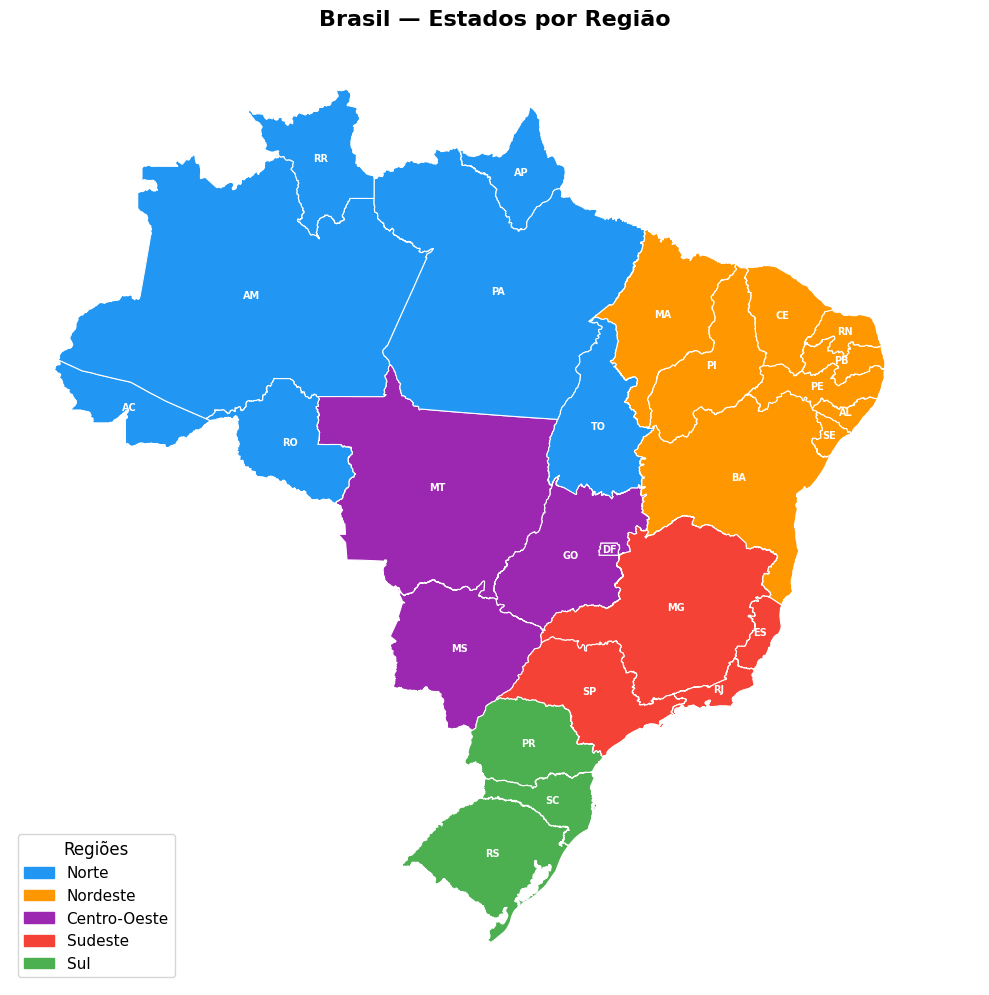

In [8]:
# Mapa colorido por região
cores_regiao = {
    'Norte':        '#2196F3',
    'Nordeste':     '#FF9800',
    'Centro-Oeste': '#9C27B0',
    'Sudeste':      '#F44336',
    'Sul':          '#4CAF50'
}

estados['cor'] = estados['regiao'].map(cores_regiao)

fig, ax = plt.subplots(figsize=(10, 10))

estados.plot(ax=ax,
             color=estados['cor'],
             edgecolor='white',
             linewidth=0.8)

# Legenda manual
patches = [mpatches.Patch(color=cor, label=reg) for reg, cor in cores_regiao.items()]
ax.legend(handles=patches, loc='lower left', title='Regiões', fontsize=11, title_fontsize=12)

# Adicionar siglas
for _, row in estados.iterrows():
    centroid = row.geometry.centroid
    ax.annotate(row['sigla'],
                xy=(centroid.x, centroid.y),
                ha='center', va='center',
                fontsize=7, color='white', fontweight='bold')

ax.set_title('Brasil — Estados por Região', fontsize=16, fontweight='bold', pad=15)
ax.axis('off')
plt.tight_layout()
plt.show()

In [9]:
import pandas as pd

# Dados fictícios de IDH por estado
# Fonte de referência: PNUD Brasil 2021
idh_data = {
    'sigla': ['AC','AL','AM','AP','BA','CE','DF','ES','GO','MA',
              'MG','MS','MT','PA','PB','PE','PI','PR','RJ','RN',
              'RO','RR','RS','SC','SE','SP','TO'],
    'idh':   [0.719,0.683,0.708,0.708,0.714,0.714,0.824,0.740,0.735,0.676,
              0.731,0.729,0.725,0.698,0.700,0.727,0.697,0.756,0.796,0.720,
              0.690,0.707,0.787,0.792,0.720,0.826,0.699]
}

df_idh = pd.DataFrame(idh_data)

# unir o GeoDataFrame com os dados de IDH
estados_idh = estados.merge(df_idh, on='sigla', how='left')

# Calcular área de cada estado

estados_idh_proj = estados_idh.to_crs(epsg=5880)
estados_idh['area_km2'] = estados_idh_proj.geometry.area / 1_000_000

print('10 maiores estados por área (km²):')
estados_idh[['name','sigla','area_km2']].sort_values('area_km2', ascending=False).head(10)

10 maiores estados por área (km²):


,name,sigla,area_km2
2,Amazonas,AM,1.601801e+06
12,Pará,PA,1.249556e+06
11,Mato Grosso,MT,9.048702e+05
9,Minas Gerais,MG,5.939968e+05
4,Bahia,BA,5.775378e+05
10,Mato Grosso do Sul,MS,3.572748e+05
7,Goiás,GO,3.411425e+05
8,Maranhão,MA,3.359251e+05
25,Tocantins,TO,2.789928e+05
21,Rio Grande do Sul,RS,2.689447e+05


In [10]:
# Calcular centroides
estados_idh['centroid'] = estados_idh.geometry.centroid

print('Centroides dos estados do Sul:')
sul = estados_idh[estados_idh['regiao'] == 'Sul'][['name','sigla','centroid']]
sul['lon'] = sul['centroid'].x
sul['lat'] = sul['centroid'].y
sul[['name','sigla','lon','lat']]

Centroides dos estados do Sul:


/tmp/ipykernel_42889/3846942488.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  estados_idh['centroid'] = estados_idh.geometry.centroid


,name,sigla,lon,lat
16,Paraná,PR,-51.616054,-24.635463
21,Rio Grande do Sul,RS,-53.319097,-29.705923
22,Santa Catarina,SC,-50.480230,-27.245667


In [11]:
# Pegar o estado de São Paulo
sao_paulo = estados_idh[estados_idh['sigla'] == 'SP'].copy()

# Criar um buffer ao redor de SP
buffer_sp = sao_paulo.geometry.buffer(0.5).iloc[0]
vizinhos_sp = estados_idh[estados_idh.geometry.intersects(buffer_sp)]
print('Estados que fazem fronteira de São Paulo:')
print(vizinhos_sp[['name', 'sigla']].to_string(index=False))

/tmp/ipykernel_42889/3390534376.py:5: UserWarning: Geometry is in a geographic CRS. Results from 'buffer' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  buffer_sp = sao_paulo.geometry.buffer(0.5).iloc[0]


Estados que fazem fronteira de São Paulo:
              name sigla
             Goiás    GO
      Minas Gerais    MG
Mato Grosso do Sul    MS
            Paraná    PR
    Rio de Janeiro    RJ
         São Paulo    SP


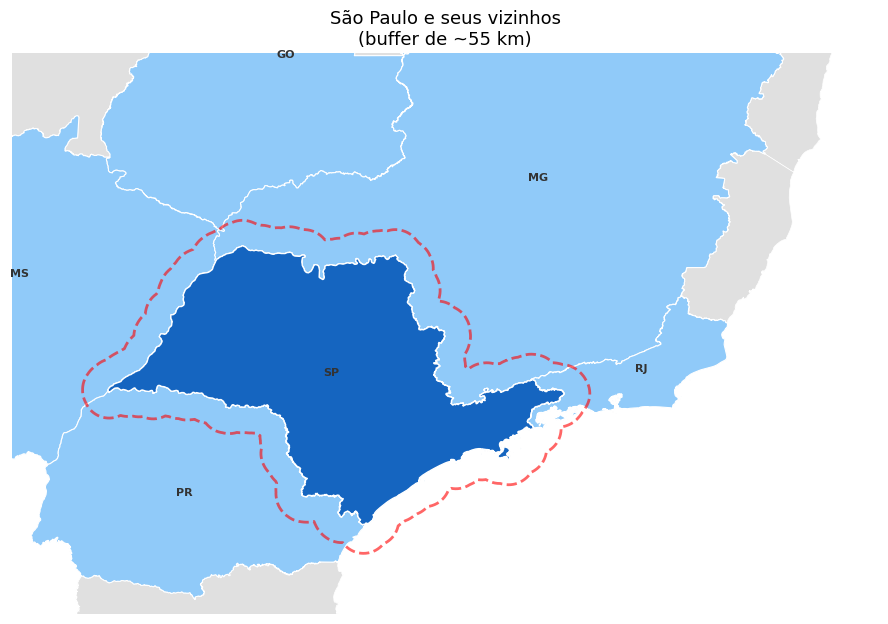

In [12]:
# Visualizar São Paulo e seus vizinhos
fig, ax = plt.subplots(figsize=(9, 7))
estados_idh.plot(ax=ax, color='#e0e0e0', edgecolor='white', linewidth=0.5)

# Vizinhos
vizinhos_sp.plot(ax=ax, color='#90CAF9', edgecolor='white', linewidth=0.8)
sao_paulo.plot(ax=ax, color='#1565C0', edgecolor='white', linewidth=1)

# Buffer
gpd.GeoSeries([buffer_sp]).plot(ax=ax, color='none', edgecolor='red',
                                  linewidth=2, linestyle='--', alpha=0.6)

# Labels
for _, row in vizinhos_sp.iterrows():
    c = row.geometry.centroid
    ax.annotate(row['sigla'], xy=(c.x, c.y), ha='center', va='center',
                fontsize=8, fontweight='bold', color='#333')

ax.set_xlim(-55, -38); ax.set_ylim(-27, -16)
ax.set_title('São Paulo e seus vizinhos\n(buffer de ~55 km)', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()

---

Documentação oficial: https://geopandas.org/en/stable/getting_started.html